# Explainable Anomaly Detection
**Pipeline:** ViT Encoder → Memory Module → Coordinate Attention → Decoder

In [7]:
import os, sys, torch, subprocess

# ── 1. Clone repo ────────────────────────────────────────────────────────────
PROJECT_DIR = '/content/explainable-anomaly-detection'
if not os.path.exists(PROJECT_DIR):
    subprocess.run(['git', 'clone', 'https://github.com/eftekin/explainable-anomaly-detection.git', PROJECT_DIR], check=True)
else:
    subprocess.run(['git', '-C', PROJECT_DIR, 'pull'])

os.chdir(PROJECT_DIR)
sys.path.insert(0, PROJECT_DIR)
print(f'Repo ready: {os.getcwd()}')

# ── 2. Kaggle token ──────────────────────────────────────────────────────────
KAGGLE_TOKEN = 'PASTE_YOUR_TOKEN_HERE'
os.environ['KAGGLE_TOKEN'] = KAGGLE_TOKEN
subprocess.run(['pip', 'install', '-q', 'kaggle'])

# ── 3. Download MVTec dataset ────────────────────────────────────────────────
DATA_DIR = f'{PROJECT_DIR}/data/mvtec'
os.makedirs(f'{PROJECT_DIR}/data', exist_ok=True)

if not os.path.exists(DATA_DIR):
    print('Downloading dataset...')
    subprocess.run(['kaggle', 'datasets', 'download', '-d', 'ipythonx/mvtec-ad',
                    '-p', f'{PROJECT_DIR}/data/', '--unzip'])

    data_contents = os.listdir(f'{PROJECT_DIR}/data/')
    print('Extracted:', data_contents)

    CATEGORIES = ['bottle','cable','capsule','carpet','grid','hazelnut','leather',
                  'metal_nut','pill','screw','tile','toothbrush','transistor','wood','zipper']

    # Case 1: categories extracted directly into data/
    if 'bottle' in data_contents:
        os.makedirs(DATA_DIR, exist_ok=True)
        for cat in CATEGORIES:
            src = f'{PROJECT_DIR}/data/{cat}'
            if os.path.exists(src):
                os.rename(src, f'{DATA_DIR}/{cat}')
        print('Moved categories into data/mvtec/')
    # Case 2: categories inside a subfolder
    else:
        for item in data_contents:
            full = f'{PROJECT_DIR}/data/{item}'
            if os.path.isdir(full) and 'bottle' in os.listdir(full):
                os.rename(full, DATA_DIR)
                print(f'Renamed {item} -> data/mvtec')
                break

print('Categories found:', sorted(os.listdir(DATA_DIR)))

# ── 4. GPU check ─────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')


Repo ready: /content/explainable-anomaly-detection
Categories found: ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']
Device: cuda
GPU   : Tesla T4


In [8]:
# Verify dataset and model
CATEGORY = 'bottle'  # change to any of the 15 MVTec categories

from config import model_cfg
from src.data import MVTecDataset
from src.models import AnomalyAutoencoder

train_ds = MVTecDataset('data/mvtec', CATEGORY, 'train', model_cfg.image_size)
test_ds  = MVTecDataset('data/mvtec', CATEGORY, 'test',  model_cfg.image_size)
print(f'Train: {len(train_ds)} | Test: {len(test_ds)}')

model = AnomalyAutoencoder(
    vit_model=model_cfg.vit_model,
    memory_size=model_cfg.memory_size,
    embed_dim=model_cfg.embed_dim,
    decoder_channels=model_cfg.decoder_channels,
).to(device)
print(f'Model params: {sum(p.numel() for p in model.parameters()):,}')
print('Ready to train.')

Train: 209 | Test: 83


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-384
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model params: 92,211,699
Ready to train.


In [9]:
import subprocess, os, sys

EPOCHS = 200
CHECKPOINT = f'results/checkpoints/{CATEGORY}/best.pth'
resume_arg = f'--resume {CHECKPOINT}' if os.path.exists(CHECKPOINT) else ''

cmd = f'python train.py --category {CATEGORY} --epochs {EPOCHS} --batch_size 8 {resume_arg}'
proc = subprocess.Popen(cmd, shell=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
for line in proc.stdout:
    print(line, end='', flush=True)
proc.wait()


2026-04-08 14:37:50,873 INFO Device: cuda
2026-04-08 14:37:50,877 INFO Training samples: 209
2026-04-08 14:37:51,066 INFO HTTP Request: HEAD https://huggingface.co/google/vit-base-patch16-384/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-08 14:37:51,067 WARNING Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-04-08 14:37:51,080 INFO HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/vit-base-patch16-384/2960116e809e2fca84146dbb240289aee7db4827/config.json "HTTP/1.1 200 OK"
2026-04-08 14:37:51,166 INFO HTTP Request: HEAD https://huggingface.co/google/vit-base-patch16-384/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-08 14:37:51,178 INFO HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/vit-base-patch16-384/2960116e809e2fca84146dbb240289aee7db4827/config.json "HTTP/1.1 200 OK"
2026-04-08 14:37:51,275 INFO HT

0

In [10]:
import subprocess, sys

cmd = f'python evaluate.py --category {CATEGORY} --checkpoint results/checkpoints/{CATEGORY}/best.pth --save_heatmaps'
proc = subprocess.Popen(cmd, shell=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
for line in proc.stdout:
    print(line, end='', flush=True)
proc.wait()


2026-04-08 15:18:50,496 INFO Test samples: 83
2026-04-08 15:18:50,734 INFO HTTP Request: HEAD https://huggingface.co/google/vit-base-patch16-384/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-08 15:18:50,735 WARNING Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-04-08 15:18:50,747 INFO HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/vit-base-patch16-384/2960116e809e2fca84146dbb240289aee7db4827/config.json "HTTP/1.1 200 OK"
2026-04-08 15:18:50,834 INFO HTTP Request: HEAD https://huggingface.co/google/vit-base-patch16-384/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-08 15:18:50,848 INFO HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/vit-base-patch16-384/2960116e809e2fca84146dbb240289aee7db4827/config.json "HTTP/1.1 200 OK"
2026-04-08 15:18:50,944 INFO HTTP Request: HEAD https://huggingface.co/google/

0

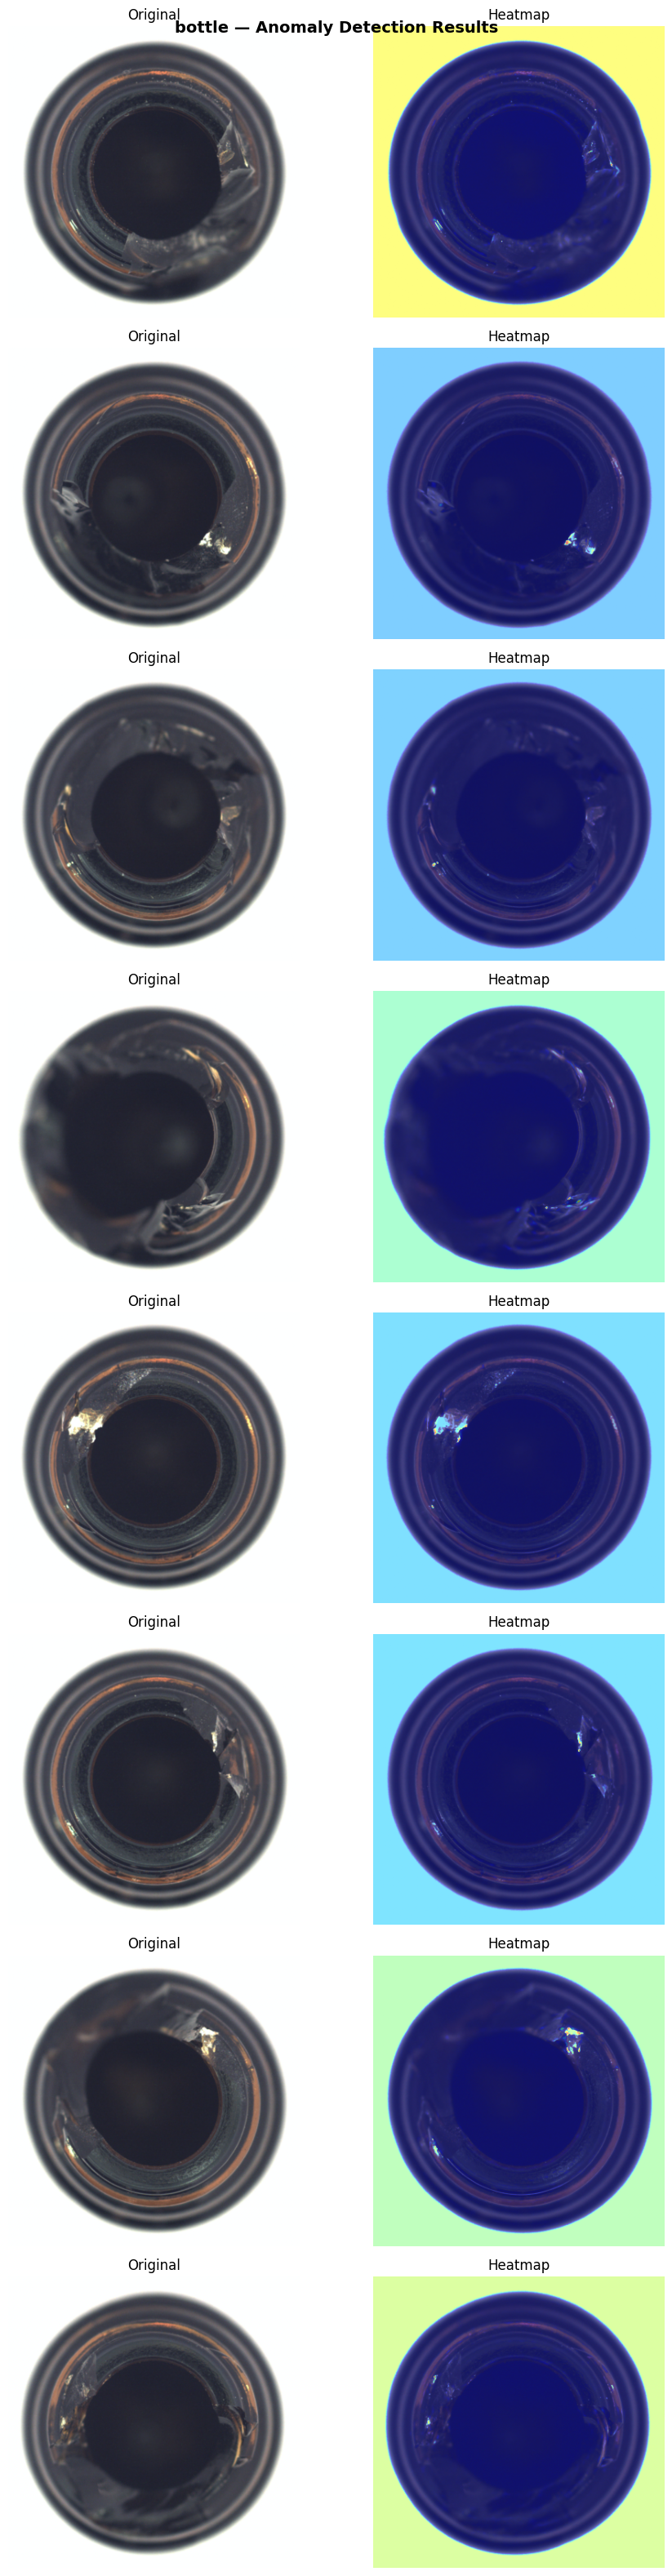

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
import cv2

images = sorted(Path(f'results/heatmaps/{CATEGORY}').glob('*label1*.png'))[:6]

fig, axes = plt.subplots(len(images), 3, figsize=(15, 5 * len(images)))
fig.suptitle(f'{CATEGORY} — Original | Heatmap | Detected Anomaly', fontsize=14, fontweight='bold')

for i, p in enumerate(images):
    img = cv2.imread(str(p))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    w = img.shape[1] // 3
    titles = ['Original', 'Heatmap', 'Detected']
    for j in range(3):
        axes[i][j].imshow(img[:, j*w:(j+1)*w])
        axes[i][j].set_title(titles[j])
        axes[i][j].axis('off')

plt.tight_layout()
plt.savefig(f'results/{CATEGORY}_results.png', dpi=150, bbox_inches='tight')
plt.show()
